# Phase 2 — Baseline CNN Classifier

Trains `BaselineCNN` (src/models/model.py) on the NEU-DET dataset using the
reusable training loop in `src/models/train.py`. Same logic as
`src/models/run_training.py` (the CLI script), but here we can inspect
curves and the confusion matrix interactively.

In [1]:
print("test")

test


In [8]:
import sys
sys.path.append('..')

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from src.data.dataset import NEUDataset, CLASS_NAMES
from src.models.model import BaselineCNN
from src.models.train import fit, evaluate

%matplotlib inline

DATA_ROOT = '../data/raw/NEU-DET'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [5]:
train_set = NEUDataset(f'{DATA_ROOT}/train')
val_set = NEUDataset(f'{DATA_ROOT}/validation')
print(f'Train samples: {len(train_set)} | Val samples: {len(val_set)}')

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

Train samples: 1440 | Val samples: 360


In [6]:
model = BaselineCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_featur

In [9]:
history = fit(
    model,
    train_loader,
    val_loader,
    device,
    epochs=15,
    lr=1e-3,
    checkpoint_path='../models/baseline_cnn.pt',
)

Epoch  1/15 | train_loss=2.7817 train_acc=0.6160 | val_loss=8.0554 val_acc=0.2417
  -> saved new best checkpoint (val_acc=0.2417)


Epoch  2/15 | train_loss=0.5735 train_acc=0.7931 | val_loss=0.5577 val_acc=0.8222
  -> saved new best checkpoint (val_acc=0.8222)


Epoch  3/15 | train_loss=0.4768 train_acc=0.8229 | val_loss=0.4678 val_acc=0.8278
  -> saved new best checkpoint (val_acc=0.8278)


Epoch  4/15 | train_loss=0.4085 train_acc=0.8542 | val_loss=0.5062 val_acc=0.8111


Epoch  5/15 | train_loss=0.3629 train_acc=0.8743 | val_loss=0.4112 val_acc=0.8444
  -> saved new best checkpoint (val_acc=0.8444)


...

Epoch 11/15 | train_loss=0.2665 train_acc=0.9090 | val_loss=0.5445 val_acc=0.7722


Epoch 12/15 | train_loss=0.2464 train_acc=0.9111 | val_loss=0.4530 val_acc=0.8083


Epoch 13/15 | train_loss=0.1832 train_acc=0.9451 | val_loss=0.4199 val_acc=0.8778


Epoch 14/15 | train_loss=0.2097 train_acc=0.9313 | val_loss=0.5141 val_acc=0.7833


Epoch 15/15 | train_loss=0.2238 train_acc=0.9257 | val_loss=0.4897 val_acc=0.8972


## Training curves

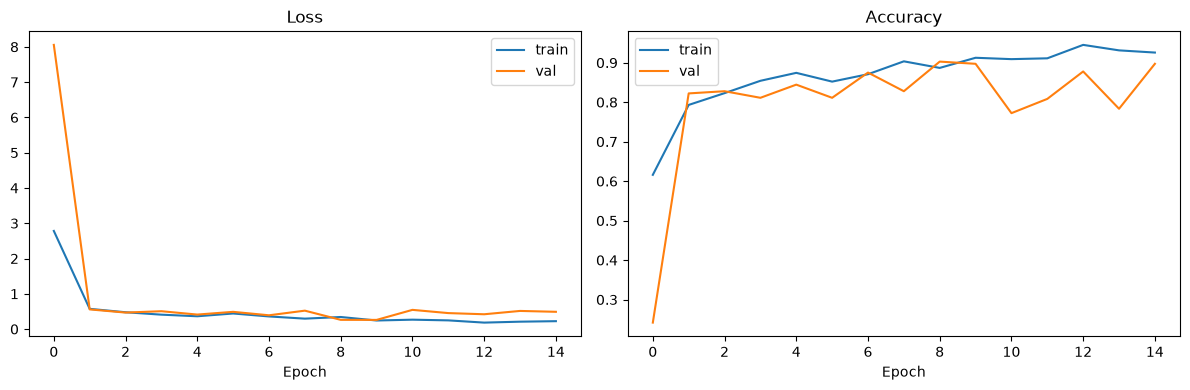

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## Confusion matrix on the validation set

Best checkpoint — val_loss=0.2616 val_acc=0.9028

                 precision    recall  f1-score   support

        crazing       0.98      1.00      0.99        60
      inclusion       0.88      0.58      0.70        60
        patches       1.00      0.98      0.99        60
 pitted_surface       0.75      0.93      0.83        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.85      0.92      0.88        60

       accuracy                           0.90       360
      macro avg       0.91      0.90      0.90       360
   weighted avg       0.91      0.90      0.90       360



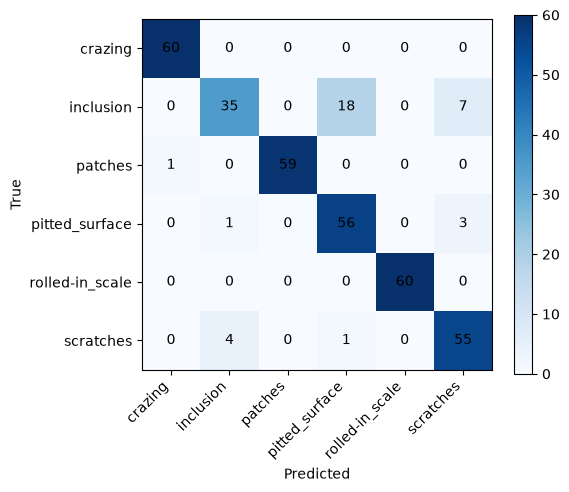

In [11]:
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report

# Load best checkpoint before final evaluation
model.load_state_dict(torch.load('../models/baseline_cnn.pt', map_location=device))

val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, nn.CrossEntropyLoss(), device)
print(f'Best checkpoint — val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im)
plt.tight_layout()
plt.show()